In [1]:
import os

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import psutil
from matplotlib.lines import Line2D

import spatioloji_s as sj
from spatioloji_s.spatial import point as spoint
from spatioloji_s.spatial import polygon as spoly
from spatioloji_s.spatial.polygon.neighborhoods import harmonize_niches

In [ ]:
sp = sj.data.spatioloji.from_pickle("xenium_data/processed_xenium_spatioloji.pkl")


Loading spatioloji from: xenium_data/processed_xenium_spatioloji.pkl


In [2]:
# ── Helper: iterate all FOVs ─────────────────────────────────────────────────
def iter_fovs(sp):
    """Yield (fov_id, sp_fov) for each FOV."""
    for fov_id in sp.fov_index:
        yield fov_id, sp.subset_by_fovs([fov_id])

## contact-based graph

In [8]:
# ── Collectors (all results stored here, NOT in sp_fov) ──────────────────────
morph_all        = []   # pd.DataFrame per FOV: shape metrics per cell
morph_class_all  = []   # pd.DataFrame per FOV: shape class per cell
contact_all      = []   # pd.DataFrame per FOV: per-pair contact lengths/fractions
free_frac_all    = []   # pd.DataFrame per FOV: free boundary fraction per cell
comp_dict        = {}   # {fov_id: comp_df} for cross-FOV niche harmonization
enrich_all       = {}   # {fov_id: z_score_df} neighborhood enrichment
hotspot_all      = []   # pd.DataFrame per FOV: Gi* results per cell

for fov_id, sp_fov in iter_fovs(sp):
    print(f"\n{'='*55}\nFOV: {fov_id}  ({sp_fov.n_cells} cells)\n{'='*55}")

    # ── Step 1: Cell morphology ───────────────────────────────────────────────
    # Computes: area, perimeter, circularity, elongation, solidity,
    #           compactness, convexity (store=False → no side effects on sp_fov)
    morph = spoly.compute_morphology(sp_fov, store=True)
    morph['fov'] = fov_id
    morph_all.append(morph)

    # Rule-based shape classification: 'round' / 'elongated' / 'irregular'
    morph_class = spoly.classify_morphology(
        sp_fov, method='threshold', circularity_thresh=0.7, solidity_thresh=0.85, elongation_thresh=2.0 ,store=True
    )  # → pd.Series indexed by cell_id
    morph_class = morph_class.rename('morph_class').to_frame()
    morph_class['fov'] = fov_id
    morph_class_all.append(morph_class)

    # ── Step 2: Build polygon contact graph ───────────────────────────────────
    # Adjacency = cells whose boundaries physically touch
    # Graph stays FOV-local (correct: FOVs are physically disconnected)
    graph = spoly.build_contact_graph(sp_fov)

    # ── Step 3: Boundary quantification ──────────────────────────────────────
    # contact_fraction → pd.DataFrame:
    #   cell_a, cell_b, contact_length_a, contact_length_b, fraction_a, fraction_b
    #   contact_length_a = portion of cell_a's OWN boundary inside cell_b
    #   (asymmetric for overlapping cells; uses unary_union to avoid
    #    double-counting at triple junctions when storing total)
    cf = spoly.contact_fraction(sp_fov, graph, store=True)
    cf['fov'] = fov_id
    contact_all.append(cf)

    # free_boundary_fraction → pd.Series:
    #   1.0 = fully isolated (exposed to ECM)
    #   0.0 = fully enclosed by neighbors
    #   Uses unary_union of all contact segments per cell before measuring
    #   → guaranteed no double-counting at triple junctions
    ff = spoly.free_boundary_fraction(sp_fov, graph, store=True)
    ff_df = ff.to_frame(name='free_boundary_fraction')
    ff_df['total_contact_fraction'] = 1.0 - ff   # exact complement
    ff_df['fov'] = fov_id
    free_frac_all.append(ff_df)

    # ── Step 4: Neighborhood composition ─────────────────────────────────────
    # For each cell: fraction of neighbors belonging to each cell type
    # store=False → we keep it in comp_dict for global harmonization
    comp = spoly.neighborhood_composition(
        sp_fov, graph,
        group_col='leiden',   # ← your cell type column
        mode='fraction',
        store=True
    )  # → pd.DataFrame: cells × cell_types
    comp_dict[fov_id] = comp

    # ── Step 5: Neighborhood enrichment ──────────────────────────────────────
    # Permutation test: which cell type pairs contact more/less than expected?
    # z_scores > 0 → enriched contact, z_scores < 0 → avoidance
    enrich = spoly.neighborhood_enrichment(
        sp_fov, graph,
        group_col='leiden',
        n_permutations=500,
        seed=42
    )
    enrich_all[fov_id] = {
        'z_scores' : enrich['z_scores'],   # cell_type × cell_type DataFrame
        'p_values' : enrich['p_values'],
        'observed' : enrich['observed'],
        'expected' : enrich['expected'],
    }

    # ── Step 6: Hotspot detection ─────────────────────────────────────────────
    # Getis-Ord Gi*: clusters of cells with significantly high total_counts
    # z_score > 0 + p_value < 0.05 → hot spot (high-expression cluster)
    # z_score < 0 + p_value < 0.05 → cold spot
    hotspots = spoly.hotspot_detection(
        sp_fov, graph,
        values='total_counts',
        store=True
    )  # → pd.DataFrame: gi_star, z_score, p_value per cell
    hotspots['fov'] = fov_id
    hotspot_all.append(hotspots)


# ── Combine per-FOV results ───────────────────────────────────────────────────
morph_df       = pd.concat(morph_all)       # shape metrics, indexed by cell_id
morph_class_df = pd.concat(morph_class_all) # morph_class + fov
contact_df     = pd.concat(contact_all)     # per-pair contact lengths/fractions
free_df        = pd.concat(free_frac_all)   # free_boundary_fraction + total + fov
hotspot_df     = pd.concat(hotspot_all)     # Gi* results, indexed by cell_id



Subsetting by FOVs: 1 FOVs requested

Subsetting by cells: 1134555 cells requested

Initializing spatioloji
[1/11] Master indices: 1,134,555 cells × 5,001 genes
[2/11] Expression matrix: sparse (10899.5 MB)
[3/10] Cell metadata: 83 columns
[4/11] Gene metadata: 15 columns
[5/11] Spatial coordinates: 1134555 cells
[6/11] Polygons: 28363705 vertices for 1134555 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,134,555
  Genes:              5,001
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    14482.0 MB

✓ Created subset: 1134555 cells, 1 FOVs
  Layers subsetted (cell axis): ['normalized_counts', 'log_normalized', 'scaled']
  Embeddings subsetted: ['X_pca', 'X_pca_variance', 'X_pca_variance_ratio', 'X_umap']

FOV:

In [9]:
morph_df

,area,perimeter,circularity,elongation,solidity,convexity,compactness,contour_entropy,fov
cell_id,,,,,,,,,
aaaaapbh-1,66.492795,31.160509,0.860549,1.242350,0.956170,0.987787,0.886065,3.159080,xenium
aaaabakn-1,164.820648,48.210700,0.891117,1.431292,0.992658,0.999146,0.857504,2.481706,xenium
aaaabhic-1,59.877610,29.040485,0.892209,1.288767,0.978596,0.987010,0.869353,2.999080,xenium
aaaabngi-1,91.238671,35.656058,0.901825,1.127644,0.979636,0.989656,0.956999,3.208884,xenium
aaaabnhl-1,128.288905,43.177165,0.864750,1.457143,0.978810,0.991809,0.850397,3.395085,xenium
...,...,...,...,...,...,...,...,...,...
oilncghd-1,179.451479,48.876210,0.943978,1.144259,0.991521,0.997246,0.948740,3.623465,xenium
oilnefna-1,125.516196,40.309271,0.970733,1.002425,0.994111,0.997470,1.022500,2.867601,xenium
oilnenmm-1,35.335116,23.415126,0.809885,1.891047,0.982430,0.989189,0.749287,3.109275,xenium


In [10]:
morph_class_df.morph_class.value_counts()

morph_class
round        760543
irregular    256149
elongated    117863
Name: count, dtype: int64

In [11]:
contact_df

,cell_a,cell_b,distance,contact_length_a,contact_length_b,fraction_a,fraction_b,fov
0,aaaaapbh-1,eepfedkp-1,0.0,3.340110e-01,3.320211e-01,1.071905e-02,6.200068e-03,xenium
1,aaaabakn-1,aaaahibn-1,0.0,2.090488e+00,2.070416e+00,4.336150e-02,2.961897e-02,xenium
2,aaaafgla-1,eepbnjio-1,0.0,4.509141e-01,4.509001e-01,1.522471e-02,1.420368e-02,xenium
3,aaaahibn-1,aaaakbdm-1,0.0,2.207844e+00,2.246649e+00,3.158499e-02,6.382827e-02,xenium
4,aaaaiedm-1,aaaailoa-1,0.0,2.273737e-13,2.273737e-13,6.218303e-15,6.548755e-15,xenium
...,...,...,...,...,...,...,...,...
229018,oillfaaa-1,oillfmcb-1,0.0,4.506037e-01,5.481707e-01,7.149707e-03,1.168208e-02,xenium
229019,oillfaaa-1,oilmgcmk-1,0.0,1.172376e+00,1.190671e+00,1.860203e-02,2.268346e-02,xenium
229020,oillmmjc-1,oillnfgh-1,0.0,1.890105e-03,2.072623e-03,3.404585e-05,3.953160e-05,xenium
229021,oillogig-1,oillppnj-1,0.0,1.584684e-03,1.654809e-03,5.686265e-05,3.118163e-05,xenium


In [12]:
free_df

,free_boundary_fraction,total_contact_fraction,fov
cell_id,,,
aaaaapbh-1,0.989281,0.010719,xenium
aaaabakn-1,0.956639,0.043361,xenium
aaaabhic-1,1.000000,0.000000,xenium
aaaabngi-1,1.000000,0.000000,xenium
aaaabnhl-1,1.000000,0.000000,xenium
...,...,...,...
oilncghd-1,1.000000,0.000000,xenium
oilnefna-1,1.000000,0.000000,xenium
oilnenmm-1,1.000000,0.000000,xenium


In [13]:
hotspot_df

,gi_star,z_score,p_value,fov
cell_id,,,,
aaaaapbh-1,1.966585,1.966585,4.923102e-02,xenium
aaaabakn-1,5.718822,5.718822,1.072651e-08,xenium
aaaabhic-1,0.717770,0.717770,4.728991e-01,xenium
aaaabngi-1,1.228349,1.228349,2.193160e-01,xenium
aaaabnhl-1,1.903187,1.903187,5.701612e-02,xenium
...,...,...,...,...
oilncghd-1,-0.688547,-0.688547,4.911081e-01,xenium
oilnefna-1,-0.597113,-0.597113,5.504322e-01,xenium
oilnenmm-1,-1.338302,-1.338302,1.807981e-01,xenium


In [14]:
comp_dict

{'xenium':               0    1    2    3    4    5    6    7    8
 cell_id                                                
 aaaaapbh-1  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 aaaabakn-1  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0
 aaaabhic-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 aaaabngi-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 aaaabnhl-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 ...         ...  ...  ...  ...  ...  ...  ...  ...  ...
 oilncghd-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 oilnefna-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 oilnenmm-1  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 oilnfbml-1  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 oilngggn-1  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0
 
 [1134555 rows x 9 columns]}

In [16]:
# ── Step 7: Global niche harmonization ───────────────────────────────────────
# Problem: niche_identification() per FOV gives locally arbitrary labels
#   (niche_0 in FOV1 ≠ niche_0 in FOV2)
# Solution: cluster all FOV composition vectors together globally
#   → labels reflect actual tissue environments, not FOV-specific numbering
# Note: graph stays FOV-local (correct), only clustering is global

global_niches = harmonize_niches(
    comp_dict,      # {fov_id: comp_df} collected in loop above
    n_niches=5,
    method='kmeans',
    seed=42
)  # → pd.Series: cell_id → 'niche_0' ... 'niche_4', NaN for isolated cells

# Write global niche labels back to the full sp object
sp.cell_meta['global_niche'] = global_niches.reindex(sp.cell_index)


[Neighborhoods] Harmonizing niches across 1 FOVs...
  → 1134555 total cells, 351686 with neighbors
  → 9 cell types in composition space
  → KMeans inertia: 1567276.0

  ✓ Global niche summary (5 niches):
    niche_0: 144834 cells | top types: 1=0.80, 7=0.07, 5=0.06
      FOVs: {'xenium': np.int64(144834)}
    niche_1: 105797 cells | top types: 0=0.97, 3=0.02, 7=0.00
      FOVs: {'xenium': np.int64(105797)}
    niche_2: 34719 cells | top types: 2=0.95, 0=0.02, 3=0.01
      FOVs: {'xenium': np.int64(34719)}
    niche_3: 55421 cells | top types: 3=0.52, 4=0.41, 1=0.03
      FOVs: {'xenium': np.int64(55421)}
    niche_4: 10915 cells | top types: 6=0.95, 3=0.02, 0=0.01
      FOVs: {'xenium': np.int64(10915)}


In [18]:
sp.cell_meta['global_niche'].value_counts(dropna=False)

global_niche
NaN        782869
niche_0    144834
niche_1    105797
niche_3     55421
niche_2     34719
niche_4     10915
Name: count, dtype: int64

In [17]:
# ── Quick summaries ───────────────────────────────────────────────────────────

# Significant hotspots across all FOVs
hot_cells  = hotspot_df[(hotspot_df['p_value'] < 0.05) & (hotspot_df['z_score'] > 0)]
cold_cells = hotspot_df[(hotspot_df['p_value'] < 0.05) & (hotspot_df['z_score'] < 0)]
print(f"\nHotspot cells : {len(hot_cells)}")
print(f"Cold spot cells: {len(cold_cells)}")

# Niche distribution across FOVs
print("\nGlobal niche distribution:")
print(sp.cell_meta['global_niche'].value_counts(dropna=False))

# Top enriched cell type contacts per FOV
print("\nTop enriched contact pair per FOV:")
for fov_id, res in enrich_all.items():
    z = res['z_scores']
    # Mask diagonal (self-contact) before finding max
    np.fill_diagonal(z.values, np.nan)
    top_pair = z.stack().idxmax()
    top_z    = z.stack().max()
    print(f"  FOV {fov_id}: {top_pair[0]} – {top_pair[1]}  (z={top_z:.2f})")

# Morphology overview
print("\nMorphology class distribution:")
print(morph_class_df['morph_class'].value_counts())

# Boundary exposure overview
print("\nBoundary exposure (free_boundary_fraction):")
print(free_df['free_boundary_fraction'].describe().round(3))



Hotspot cells : 78499
Cold spot cells: 373

Global niche distribution:
global_niche
NaN        782869
niche_0    144834
niche_1    105797
niche_3     55421
niche_2     34719
niche_4     10915
Name: count, dtype: int64

Top enriched contact pair per FOV:
  FOV xenium: 1 – 4  (z=13.72)

Morphology class distribution:
morph_class
round        760543
irregular    256149
elongated    117863
Name: count, dtype: int64

Boundary exposure (free_boundary_fraction):
count    1134555.000
mean           0.993
std            0.020
min            0.000
25%            1.000
50%            1.000
75%            1.000
max            1.000
Name: free_boundary_fraction, dtype: float64


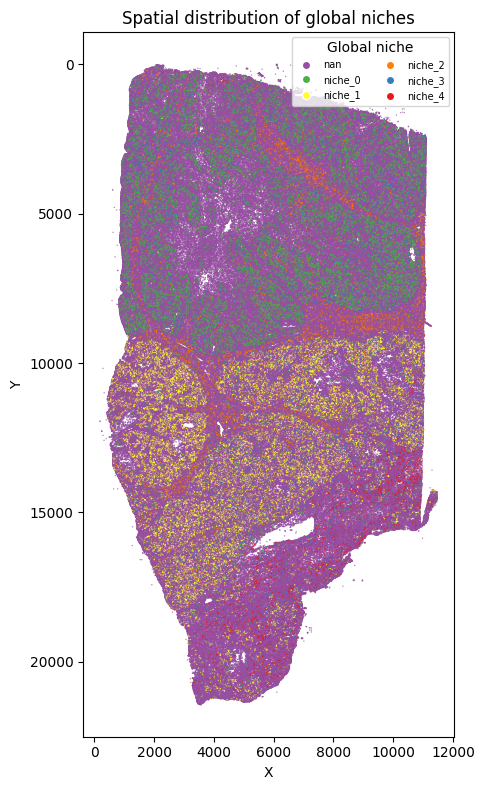

In [24]:
cluster_ids = sp.cell_meta["global_niche"].astype(str)
unique_clusters = sorted(cluster_ids.dropna().unique())

# --- generate random tab10 colors ---
cmap = plt.get_cmap("Set1")
rng = np.random.default_rng(42)
color_indices = rng.permutation(len(unique_clusters)) % 10

color_dict = {cl: cmap(i) for cl, i in zip(unique_clusters, color_indices)}

colors = cluster_ids.map(color_dict)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=colors,
    s=1,
    alpha=0.7,
    linewidths=0
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of global niches")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# --- legend ---
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=cl,
        markerfacecolor=color_dict[cl],
        markersize=6
    )
    for cl in unique_clusters
]

ax.legend(
    handles=legend_elements,
    title="Global niche",
    loc="upper right",
    ncol=2,
    fontsize=7
)

plt.tight_layout()
plt.show()

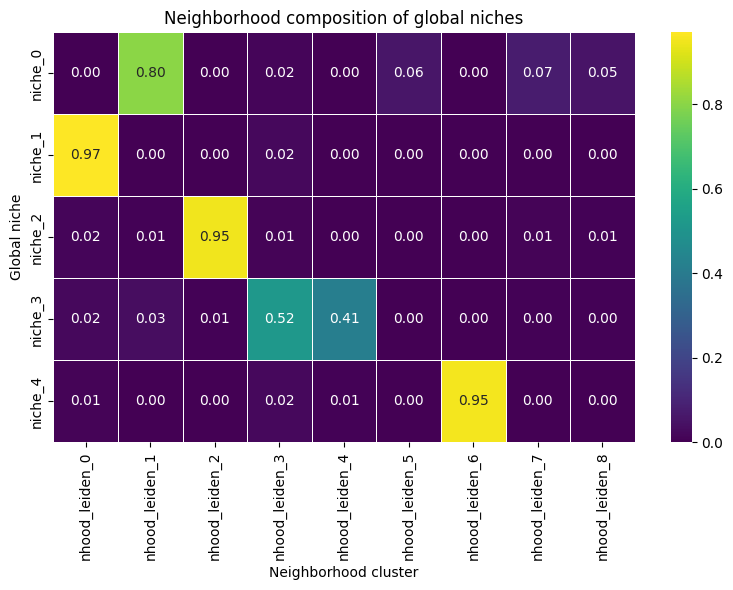

In [38]:
nhoods = sp.cell_meta.loc[:, sp.cell_meta.columns.str.startswith('nhood_leiden')].copy()
nhoods['global_niche'] = sp.cell_meta['global_niche']
nhoods = nhoods.groupby('global_niche').mean()


plt.figure(figsize=(8, 6))

sns.heatmap(
    nhoods,
    cmap="viridis",
    annot=True,          # show values
    fmt=".2f",
    linewidths=0.5
)

plt.xlabel("Neighborhood cluster")
plt.ylabel("Global niche")
plt.title("Neighborhood composition of global niches")

plt.tight_layout()
plt.show()

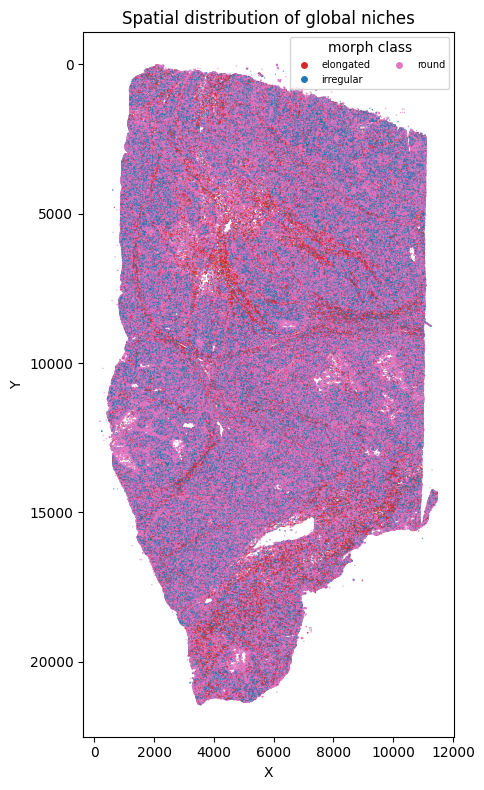

In [51]:
cluster_ids = sp.cell_meta["morph_class"].astype(str)
unique_clusters = sorted(cluster_ids.dropna().unique())

color_dict = {cl: i for cl, i in zip(unique_clusters, ['#d62728', '#1f77b4', '#e377c2'])}

colors = cluster_ids.map(color_dict)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=colors,
    s=1,
    alpha=0.7,
    linewidths=0
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of global niches")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# --- legend ---
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=cl,
        markerfacecolor=color_dict[cl],
        markersize=6
    )
    for cl in unique_clusters
]

ax.legend(
    handles=legend_elements,
    title="morph class",
    loc="upper right",
    ncol=2,
    fontsize=7
)

plt.tight_layout()
plt.show()

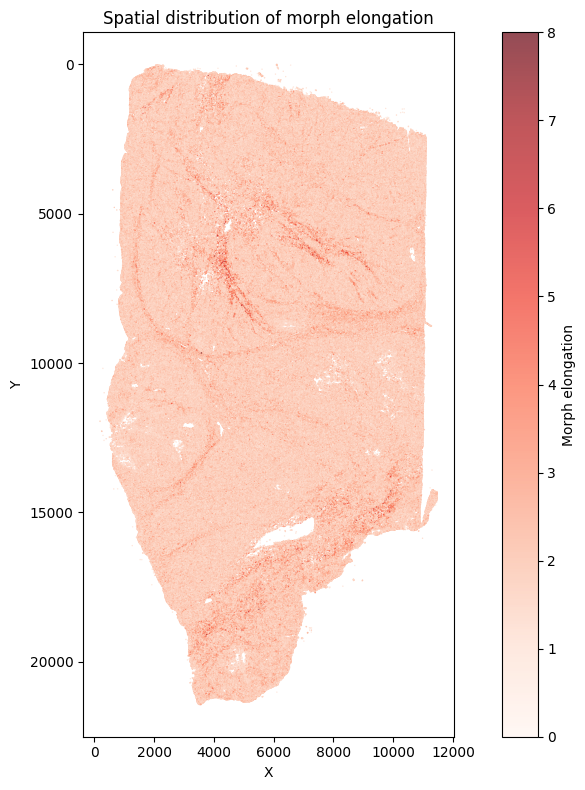

In [54]:
values = sp.cell_meta["morph_elongation"]

fig, ax = plt.subplots(figsize=(10,8))

sc = ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=values,              # continuous values
    cmap="Reds",        # continuous colormap
    s=1,
    alpha=0.7,
    linewidths=0,
    vmin=0,
    vmax=8
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of morph elongation")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# colorbar instead of legend
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Morph elongation")

plt.tight_layout()
plt.show()

## buffering graph

In [4]:
# ── Collectors (all results stored here, NOT in sp_fov) ──────────────────────
morph_all        = []   # pd.DataFrame per FOV: shape metrics per cell
morph_class_all  = []   # pd.DataFrame per FOV: shape class per cell
contact_all      = []   # pd.DataFrame per FOV: per-pair contact lengths/fractions
free_frac_all    = []   # pd.DataFrame per FOV: free boundary fraction per cell
comp_dict        = {}   # {fov_id: comp_df} for cross-FOV niche harmonization
enrich_all       = {}   # {fov_id: z_score_df} neighborhood enrichment
hotspot_all      = []   # pd.DataFrame per FOV: Gi* results per cell

for fov_id, sp_fov in iter_fovs(sp):
    print(f"\n{'='*55}\nFOV: {fov_id}  ({sp_fov.n_cells} cells)\n{'='*55}")

    # ── Step 1: Cell morphology ───────────────────────────────────────────────
    # Computes: area, perimeter, circularity, elongation, solidity,
    #           compactness, convexity (store=False → no side effects on sp_fov)
    morph = spoly.compute_morphology(sp_fov, store=True)
    morph['fov'] = fov_id
    morph_all.append(morph)

    # Rule-based shape classification: 'round' / 'elongated' / 'irregular'
    morph_class = spoly.classify_morphology(
        sp_fov, method='threshold', store=True
    )  # → pd.Series indexed by cell_id
    morph_class = morph_class.rename('morph_class').to_frame()
    morph_class['fov'] = fov_id
    morph_class_all.append(morph_class)

    # ── Step 2: Build polygon contact graph ───────────────────────────────────
    # Adjacency = cells whose boundaries physically touch
    # Graph stays FOV-local (correct: FOVs are physically disconnected)
    graph = spoly.build_buffer_graph(sp_fov, buffer_distance=2)

    # ── Step 3: Boundary quantification ──────────────────────────────────────
    # contact_fraction → pd.DataFrame:
    #   cell_a, cell_b, contact_length_a, contact_length_b, fraction_a, fraction_b
    #   contact_length_a = portion of cell_a's OWN boundary inside cell_b
    #   (asymmetric for overlapping cells; uses unary_union to avoid
    #    double-counting at triple junctions when storing total)
    cf = spoly.contact_fraction(sp_fov, graph, store=True)
    cf['fov'] = fov_id
    contact_all.append(cf)

    # free_boundary_fraction → pd.Series:
    #   1.0 = fully isolated (exposed to ECM)
    #   0.0 = fully enclosed by neighbors
    #   Uses unary_union of all contact segments per cell before measuring
    #   → guaranteed no double-counting at triple junctions
    ff = spoly.free_boundary_fraction(sp_fov, graph, store=True)
    ff_df = ff.to_frame(name='free_boundary_fraction')
    ff_df['total_contact_fraction'] = 1.0 - ff   # exact complement
    ff_df['fov'] = fov_id
    free_frac_all.append(ff_df)

    # ── Step 4: Neighborhood composition ─────────────────────────────────────
    # For each cell: fraction of neighbors belonging to each cell type
    # store=False → we keep it in comp_dict for global harmonization
    comp = spoly.neighborhood_composition(
        sp_fov, graph,
        group_col='leiden',   # ← your cell type column
        mode='fraction',
        store=True
    )  # → pd.DataFrame: cells × cell_types
    comp_dict[fov_id] = comp

    # ── Step 5: Neighborhood enrichment ──────────────────────────────────────
    # Permutation test: which cell type pairs contact more/less than expected?
    # z_scores > 0 → enriched contact, z_scores < 0 → avoidance
    enrich = spoly.neighborhood_enrichment(
        sp_fov, graph,
        group_col='leiden',
        n_permutations=500,
        seed=42
    )
    enrich_all[fov_id] = {
        'z_scores' : enrich['z_scores'],   # cell_type × cell_type DataFrame
        'p_values' : enrich['p_values'],
        'observed' : enrich['observed'],
        'expected' : enrich['expected'],
    }

    # ── Step 6: Hotspot detection ─────────────────────────────────────────────
    # Getis-Ord Gi*: clusters of cells with significantly high total_counts
    # z_score > 0 + p_value < 0.05 → hot spot (high-expression cluster)
    # z_score < 0 + p_value < 0.05 → cold spot
    hotspots = spoly.hotspot_detection(
        sp_fov, graph,
        values='total_counts',
        store=True
    )  # → pd.DataFrame: gi_star, z_score, p_value per cell
    hotspots['fov'] = fov_id
    hotspot_all.append(hotspots)


# ── Combine per-FOV results ───────────────────────────────────────────────────
morph_df       = pd.concat(morph_all)       # shape metrics, indexed by cell_id
morph_class_df = pd.concat(morph_class_all) # morph_class + fov
contact_df     = pd.concat(contact_all)     # per-pair contact lengths/fractions
free_df        = pd.concat(free_frac_all)   # free_boundary_fraction + total + fov
hotspot_df     = pd.concat(hotspot_all)     # Gi* results, indexed by cell_id



Subsetting by FOVs: 1 FOVs requested

Subsetting by cells: 1134555 cells requested

Initializing spatioloji
[1/11] Master indices: 1,134,555 cells × 5,001 genes
[2/11] Expression matrix: sparse (10899.5 MB)
[3/10] Cell metadata: 83 columns
[4/11] Gene metadata: 15 columns
[5/11] Spatial coordinates: 1134555 cells
[6/11] Polygons: 28363705 vertices for 1134555 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,134,555
  Genes:              5,001
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    14482.0 MB

✓ Created subset: 1134555 cells, 1 FOVs
  Layers subsetted (cell axis): ['normalized_counts', 'log_normalized', 'scaled']
  Embeddings subsetted: ['X_pca', 'X_pca_variance', 'X_pca_variance_ratio', 'X_umap']

FOV:

In [9]:
# ── Step 7: Global niche harmonization ───────────────────────────────────────
# Problem: niche_identification() per FOV gives locally arbitrary labels
#   (niche_0 in FOV1 ≠ niche_0 in FOV2)
# Solution: cluster all FOV composition vectors together globally
#   → labels reflect actual tissue environments, not FOV-specific numbering
# Note: graph stays FOV-local (correct), only clustering is global

global_niches = harmonize_niches(
    comp_dict,      # {fov_id: comp_df} collected in loop above
    n_niches=5,
    method='kmeans',
    seed=42
)  # → pd.Series: cell_id → 'niche_0' ... 'niche_4', NaN for isolated cells

# Write global niche labels back to the full sp object
sp.cell_meta['global_niche'] = global_niches.reindex(sp.cell_index)


[Neighborhoods] Harmonizing niches across 1 FOVs...
  → 1134555 total cells, 1109289 with neighbors
  → 9 cell types in composition space
  → KMeans inertia: 5393459.3

  ✓ Global niche summary (5 niches):
    niche_0: 281829 cells | top types: 3=0.28, 6=0.17, 4=0.15
      FOVs: {'xenium': np.int64(281829)}
    niche_1: 313600 cells | top types: 1=0.83, 4=0.07, 3=0.07
      FOVs: {'xenium': np.int64(313600)}
    niche_2: 316526 cells | top types: 0=0.81, 3=0.07, 4=0.05
      FOVs: {'xenium': np.int64(316526)}
    niche_3: 129028 cells | top types: 2=0.82, 7=0.04, 4=0.04
      FOVs: {'xenium': np.int64(129028)}
    niche_4: 68306 cells | top types: 5=0.83, 3=0.04, 8=0.03
      FOVs: {'xenium': np.int64(68306)}


In [12]:
global_niches.value_counts(dropna=False)

niche_2    316526
niche_1    313600
niche_0    281829
niche_3    129028
niche_4     68306
NaN         25266
Name: count, dtype: int64

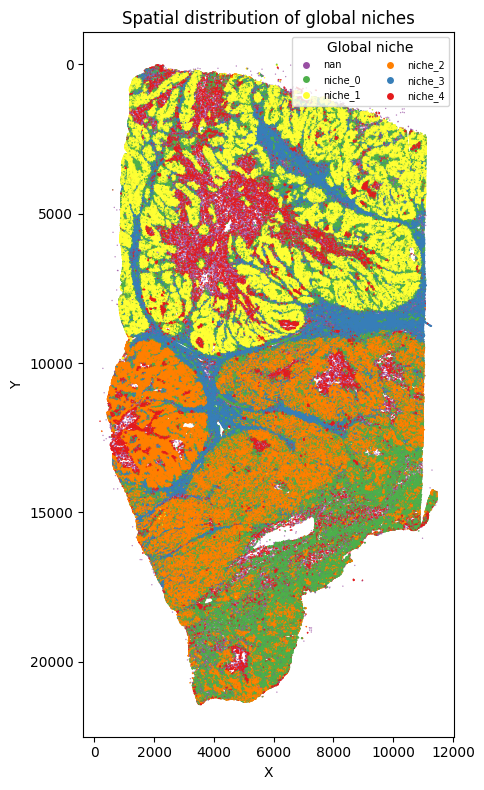

In [13]:
cluster_ids = sp.cell_meta["global_niche"].astype(str)
unique_clusters = sorted(cluster_ids.dropna().unique())

# --- generate random tab10 colors ---
cmap = plt.get_cmap("Set1")
rng = np.random.default_rng(42)
color_indices = rng.permutation(len(unique_clusters)) % 10

color_dict = {cl: cmap(i) for cl, i in zip(unique_clusters, color_indices)}

colors = cluster_ids.map(color_dict)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=colors,
    s=1,
    alpha=0.7,
    linewidths=0
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of global niches")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# --- legend ---
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=cl,
        markerfacecolor=color_dict[cl],
        markersize=6
    )
    for cl in unique_clusters
]

ax.legend(
    handles=legend_elements,
    title="Global niche",
    loc="upper right",
    ncol=2,
    fontsize=7
)

plt.tight_layout()
plt.show()

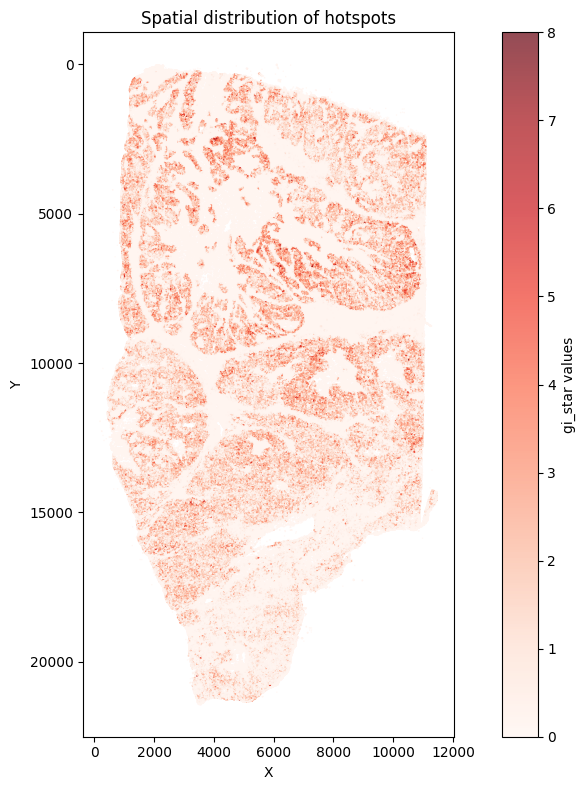

In [24]:
values = sp_fov.cell_meta["gi_star_"+"total_counts"]

fig, ax = plt.subplots(figsize=(10,8))

sc = ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=values,              # continuous values
    cmap="Reds",        # continuous colormap
    s=1,
    alpha=0.7,
    linewidths=0,
    vmin=0,
    vmax=8
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of hotspots")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# colorbar instead of legend
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("gi_star values")

plt.tight_layout()
plt.show()

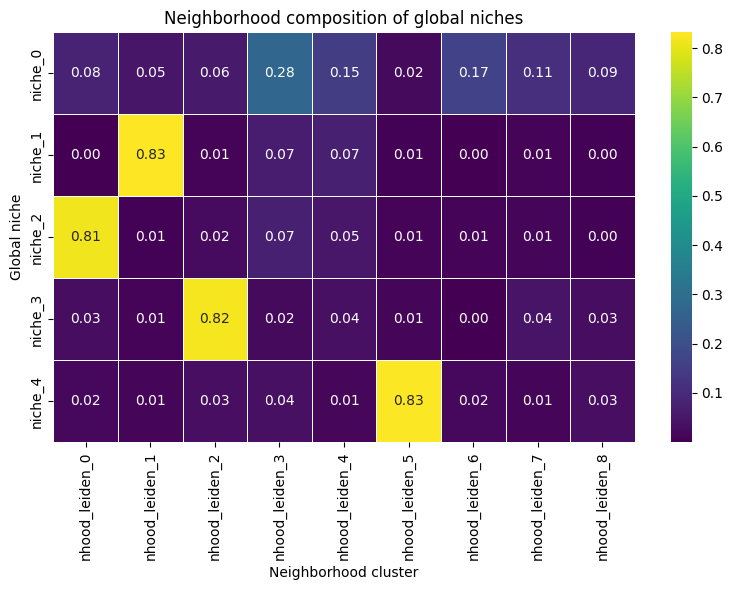

In [21]:
nhoods = sp_fov.cell_meta.loc[:, sp_fov.cell_meta.columns.str.startswith('nhood_leiden')].copy()
nhoods['global_niche'] = sp.cell_meta['global_niche']
nhoods = nhoods.groupby('global_niche').mean()


plt.figure(figsize=(8, 6))

sns.heatmap(
    nhoods,
    cmap="viridis",
    annot=True,          # show values
    fmt=".2f",
    linewidths=0.5
)

plt.xlabel("Neighborhood cluster")
plt.ylabel("Global niche")
plt.title("Neighborhood composition of global niches")

plt.tight_layout()
plt.show()

In [5]:
morph_df

,area,perimeter,circularity,elongation,solidity,convexity,compactness,contour_entropy,fov
cell_id,,,,,,,,,
aaaaapbh-1,66.492795,31.160509,0.860549,1.242350,0.956170,0.987787,0.886065,3.159080,xenium
aaaabakn-1,164.820648,48.210700,0.891117,1.431292,0.992658,0.999146,0.857504,2.481706,xenium
aaaabhic-1,59.877610,29.040485,0.892209,1.288767,0.978596,0.987010,0.869353,2.999080,xenium
aaaabngi-1,91.238671,35.656058,0.901825,1.127644,0.979636,0.989656,0.956999,3.208884,xenium
aaaabnhl-1,128.288905,43.177165,0.864750,1.457143,0.978810,0.991809,0.850397,3.395085,xenium
...,...,...,...,...,...,...,...,...,...
oilncghd-1,179.451479,48.876210,0.943978,1.144259,0.991521,0.997246,0.948740,3.623465,xenium
oilnefna-1,125.516196,40.309271,0.970733,1.002425,0.994111,0.997470,1.022500,2.867601,xenium
oilnenmm-1,35.335116,23.415126,0.809885,1.891047,0.982430,0.989189,0.749287,3.109275,xenium


In [6]:
contact_df

,cell_a,cell_b,distance,contact_length_a,contact_length_b,fraction_a,fraction_b,fov
0,aaaaapbh-1,aaaabakn-1,0.360781,5.645592,5.903161,0.181178,0.122445,xenium
1,aaaaapbh-1,aaaabngi-1,0.103078,11.419562,11.406870,0.366475,0.319914,xenium
2,aaaaapbh-1,aaaddhjo-1,1.202011,3.407330,3.630222,0.109348,0.120318,xenium
3,aaaaapbh-1,eepdpejd-1,0.067137,9.110213,8.961111,0.292364,0.170614,xenium
4,aaaaapbh-1,eepfedkp-1,0.000000,8.065797,7.768581,0.258847,0.145068,xenium
...,...,...,...,...,...,...,...,...
2497896,oilmbana-1,oilmbjem-1,1.373644,8.028574,8.501206,0.157062,0.210001,xenium
2497897,oilmbjem-1,oilmckik-1,0.041789,9.639817,9.424146,0.238127,0.402555,xenium
2497898,oilmgbin-1,oilmglgn-1,0.436966,5.640926,5.887185,0.185542,0.239278,xenium
2497899,oilncghd-1,oilnefna-1,0.977166,8.201702,8.028376,0.167806,0.199169,xenium


In [7]:
free_df

,free_boundary_fraction,total_contact_fraction,fov
cell_id,,,
aaaaapbh-1,0.000000,1.000000,xenium
aaaabakn-1,0.000000,1.000000,xenium
aaaabhic-1,0.000000,1.000000,xenium
aaaabngi-1,0.000000,1.000000,xenium
aaaabnhl-1,0.000000,1.000000,xenium
...,...,...,...
oilncghd-1,0.674822,0.325178,xenium
oilnefna-1,0.498890,0.501110,xenium
oilnenmm-1,0.722832,0.277168,xenium


In [8]:
hotspot_df

,gi_star,z_score,p_value,fov
cell_id,,,,
aaaaapbh-1,3.832699,3.832699,0.000127,xenium
aaaabakn-1,4.703794,4.703794,0.000003,xenium
aaaabhic-1,0.837521,0.837521,0.402300,xenium
aaaabngi-1,2.251369,2.251369,0.024362,xenium
aaaabnhl-1,2.344340,2.344340,0.019061,xenium
...,...,...,...,...
oilncghd-1,-1.199608,-1.199608,0.230292,xenium
oilnefna-1,-1.604875,-1.604875,0.108521,xenium
oilnenmm-1,-1.720997,-1.720997,0.085251,xenium


In [22]:
sp_fov.cell_meta

,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,nhood_leiden_1,nhood_leiden_2,nhood_leiden_3,nhood_leiden_4,nhood_leiden_5,nhood_leiden_6,nhood_leiden_7,nhood_leiden_8,gi_star_total_counts,gi_star_total_counts_pval
cell_id,,,,,,,,,,,,,,,,,,,,,
aaaaapbh-1,1258.716675,645.378845,2244,0,0,0,0,2,2246,69.901878,...,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,3.832699,0.000127
aaaabakn-1,1271.045410,644.860291,5144,0,0,1,0,8,5153,168.161881,...,0.625000,0.000000,0.125000,0.250000,0.0,0.0,0.0,0.0,4.703794,0.000003
aaaabhic-1,1260.016846,626.994629,2584,0,0,0,0,3,2587,62.451096,...,0.600000,0.000000,0.200000,0.200000,0.0,0.0,0.0,0.0,0.837521,0.402300
aaaabngi-1,1260.382812,636.802917,3214,1,0,0,0,3,3218,95.234535,...,0.800000,0.000000,0.000000,0.200000,0.0,0.0,0.0,0.0,2.251369,0.024362
aaaabnhl-1,1263.028809,700.631958,4040,0,0,0,0,12,4052,131.088599,...,0.666667,0.000000,0.166667,0.166667,0.0,0.0,0.0,0.0,2.344340,0.019061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oilncghd-1,2641.017822,9102.448242,848,0,0,0,0,1,849,183.785944,...,0.000000,0.500000,0.500000,0.000000,0.0,0.0,0.0,0.0,-1.199608,0.230292
oilnefna-1,2654.033447,9095.945312,960,0,0,0,0,2,962,128.559848,...,0.000000,0.666667,0.000000,0.333333,0.0,0.0,0.0,0.0,-1.604875,0.108521
oilnenmm-1,2699.451904,9303.602539,46,0,0,0,0,0,46,37.479689,...,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,-1.720997,0.085251


## KNN graph

In [4]:
# ── Collectors (all results stored here, NOT in sp_fov) ──────────────────────
morph_all        = []   # pd.DataFrame per FOV: shape metrics per cell
morph_class_all  = []   # pd.DataFrame per FOV: shape class per cell
comp_dict        = {}   # {fov_id: comp_df} for cross-FOV niche harmonization
enrich_all       = {}   # {fov_id: z_score_df} neighborhood enrichment
hotspot_all      = []   # pd.DataFrame per FOV: Gi* results per cell
ctx_morph_all    = []   # pd.DataFrame per FOV: context shape features per cell

for fov_id, sp_fov in iter_fovs(sp):
    print(f"\n{'='*55}\nFOV: {fov_id}  ({sp_fov.n_cells} cells)\n{'='*55}")

    # ── Step 1: Cell morphology ───────────────────────────────────────────────
    # Computes: area, perimeter, circularity, elongation, solidity,
    #           compactness, convexity (store=False → no side effects on sp_fov)
    morph = spoly.compute_morphology(sp_fov, store=True)
    morph['fov'] = fov_id
    morph_all.append(morph)

    # Rule-based shape classification: 'round' / 'elongated' / 'irregular'
    morph_class = spoly.classify_morphology(
        sp_fov, method='threshold', circularity_thresh=0.7, solidity_thresh=0.85, elongation_thresh=2.0 ,store=True
    )  # → pd.Series indexed by cell_id
    morph_class = morph_class.rename('morph_class').to_frame()
    morph_class['fov'] = fov_id
    morph_class_all.append(morph_class)

    # ── Step 2: Build polygon contact graph ───────────────────────────────────
    # Adjacency = cells whose boundaries physically touch
    # Graph stays FOV-local (correct: FOVs are physically disconnected)
    graph = spoly.build_knn_graph(sp_fov, k=6, candidate_multiplier=2, symmetrize=False)

    # ── Step 3: Context morphology ──────────────────────────────────────────
    ctx_morph = spoly.compute_context_morphology(sp_fov, graph, store=True)
    ctx_morph['fov'] = fov_id
    ctx_morph_all.append(ctx_morph)

    # ── Step 4: Neighborhood composition ─────────────────────────────────────
    # For each cell: fraction of neighbors belonging to each cell type
    # store=False → we keep it in comp_dict for global harmonization
    comp = spoly.neighborhood_composition(
        sp_fov, graph,
        group_col='leiden',   # ← your cell type column
        mode='fraction',
        store=True
    )  # → pd.DataFrame: cells × cell_types
    comp_dict[fov_id] = comp

    # ── Step 5: Neighborhood enrichment ──────────────────────────────────────
    # Permutation test: which cell type pairs contact more/less than expected?
    # z_scores > 0 → enriched contact, z_scores < 0 → avoidance
    enrich = spoly.neighborhood_enrichment(
        sp_fov, graph,
        group_col='leiden',
        n_permutations=500,
        seed=42
    )
    enrich_all[fov_id] = {
        'z_scores' : enrich['z_scores'],   # cell_type × cell_type DataFrame
        'p_values' : enrich['p_values'],
        'observed' : enrich['observed'],
        'expected' : enrich['expected'],
    }

    # ── Step 6: Hotspot detection ─────────────────────────────────────────────
    # Getis-Ord Gi*: clusters of cells with significantly high total_counts
    # z_score > 0 + p_value < 0.05 → hot spot (high-expression cluster)
    # z_score < 0 + p_value < 0.05 → cold spot
    hotspots = spoly.hotspot_detection(
        sp_fov, graph,
        values='THY1',
        store=True
    )  # → pd.DataFrame: gi_star, z_score, p_value per cell
    hotspots['fov'] = fov_id
    hotspot_all.append(hotspots)


# ── Combine per-FOV results ───────────────────────────────────────────────────
morph_df       = pd.concat(morph_all)       # shape metrics, indexed by cell_id
morph_class_df = pd.concat(morph_class_all) # morph_class + fov
hotspot_df     = pd.concat(hotspot_all)     # Gi* results, indexed by cell_id
ctx_morph_df   = pd.concat(ctx_morph_all)   # context morphology, indexed by cell_id
hotspot_df     = pd.concat(hotspot_all)     # Gi* results, indexed by cell_id




Subsetting by FOVs: 1 FOVs requested

Subsetting by cells: 1134555 cells requested

Initializing spatioloji
[1/11] Master indices: 1,134,555 cells × 5,001 genes
[2/11] Expression matrix: sparse (10899.5 MB)
[3/10] Cell metadata: 83 columns
[4/11] Gene metadata: 15 columns
[5/11] Spatial coordinates: 1134555 cells
[6/11] Polygons: 28363705 vertices for 1134555 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,134,555
  Genes:              5,001
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    14482.0 MB

✓ Created subset: 1134555 cells, 1 FOVs
  Layers subsetted (cell axis): ['normalized_counts', 'log_normalized', 'scaled']
  Embeddings subsetted: ['X_pca', 'X_pca_variance', 'X_pca_variance_ratio', 'X_umap']

FOV:

In [5]:
# ── Step 7: Global niche harmonization ───────────────────────────────────────
# Problem: niche_identification() per FOV gives locally arbitrary labels
#   (niche_0 in FOV1 ≠ niche_0 in FOV2)
# Solution: cluster all FOV composition vectors together globally
#   → labels reflect actual tissue environments, not FOV-specific numbering
# Note: graph stays FOV-local (correct), only clustering is global

global_niches = harmonize_niches(
    comp_dict,      # {fov_id: comp_df} collected in loop above
    n_niches=5,
    method='kmeans',
    seed=42
)  # → pd.Series: cell_id → 'niche_0' ... 'niche_4', NaN for isolated cells

# Write global niche labels back to the full sp object
sp_fov.cell_meta['global_niche'] = global_niches.reindex(sp.cell_index)


[Neighborhoods] Harmonizing niches across 1 FOVs...
  → 1134555 total cells, 1134555 with neighbors
  → 9 cell types in composition space
  → KMeans inertia: 5369023.4

  ✓ Global niche summary (5 niches):
    niche_0: 342504 cells | top types: 1=0.78, 4=0.09, 3=0.09
      FOVs: {'xenium': np.int64(342504)}
    niche_1: 413081 cells | top types: 0=0.66, 3=0.16, 4=0.09
      FOVs: {'xenium': np.int64(413081)}
    niche_2: 76081 cells | top types: 6=0.61, 3=0.18, 4=0.06
      FOVs: {'xenium': np.int64(76081)}
    niche_3: 228749 cells | top types: 2=0.51, 7=0.15, 8=0.10
      FOVs: {'xenium': np.int64(228749)}
    niche_4: 74140 cells | top types: 5=0.78, 8=0.05, 3=0.05
      FOVs: {'xenium': np.int64(74140)}


In [3]:
# sp_fov.to_pickle("xenium_data/morph_xenium_spatioloji.pkl") # optional
sp_fov = sj.data.core.spatioloji.from_pickle("xenium_data/morph_xenium_spatioloji.pkl") # optional


Loading spatioloji from: xenium_data/morph_xenium_spatioloji.pkl
✓ Loaded: 1,134,555 cells × 5,001 genes


In [7]:
morph_df

,area,perimeter,circularity,elongation,solidity,convexity,compactness,rectangularity,eccentricity,feret_max,feret_min,feret_ratio,n_concavities,contour_entropy,fov
cell_id,,,,,,,,,,,,,,,
aaaaapbh-1,66.492795,31.160509,0.860549,1.242350,0.956170,0.987787,0.886065,0.766063,0.593375,10.483812,8.358589,0.797285,4,3.159080,xenium
aaaabakn-1,164.820648,48.210700,0.891117,1.431292,0.992658,0.999146,0.857504,0.826591,0.715445,18.096163,11.784096,0.651193,2,2.481706,xenium
aaaabhic-1,59.877610,29.040485,0.892209,1.288767,0.978596,0.987010,0.869353,0.764992,0.630812,10.102135,7.793212,0.771442,5,2.999080,xenium
aaaabngi-1,91.238671,35.656058,0.901825,1.127644,0.979636,0.989656,0.956999,0.811119,0.462145,12.030170,9.977513,0.829374,6,3.208884,xenium
aaaabnhl-1,128.288905,43.177165,0.864750,1.457143,0.978810,0.991809,0.850397,0.827629,0.727342,15.413210,10.313966,0.669164,4,3.395085,xenium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oilncghd-1,179.451479,48.876210,0.943978,1.144259,0.991521,0.997246,0.948740,0.808926,0.486056,16.608952,13.923775,0.838330,5,3.623465,xenium
oilnefna-1,125.516196,40.309271,0.970733,1.002425,0.994111,0.997470,1.022500,0.823129,0.069510,13.349139,12.328447,0.923539,3,2.867601,xenium
oilnenmm-1,35.335116,23.415126,0.809885,1.891047,0.982430,0.989189,0.749287,0.833852,0.848742,8.968280,4.733774,0.527835,5,3.109275,xenium


  Saved: xenium_plots/xenium_global_niche_dot_categorical.png


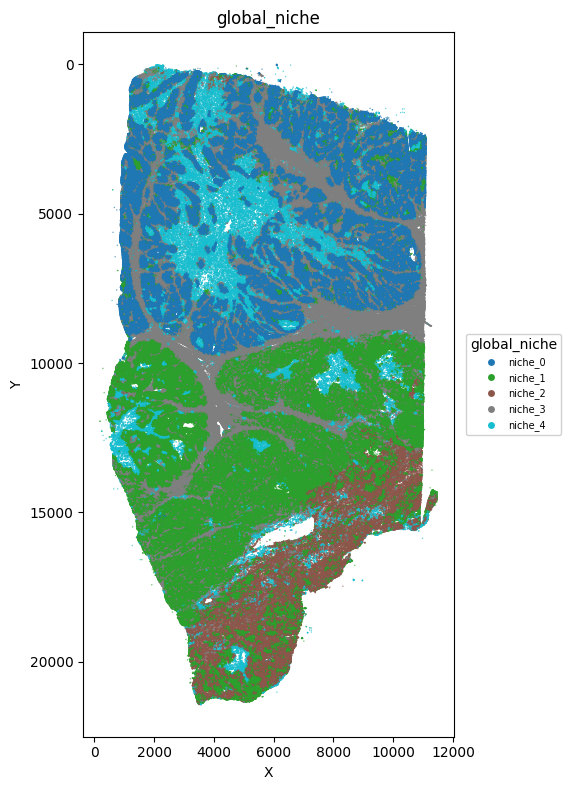

In [4]:
sj.visualization.xenium_plot_spatial(sp_fov, 
                                     values='global_niche', 
                                     save_dir='xenium_plots',
                                     mode='dot', 
                                     show=True)

Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 1134555 cells
  Saved: xenium_plots/xenium_global_niche_polygon_categorical.png


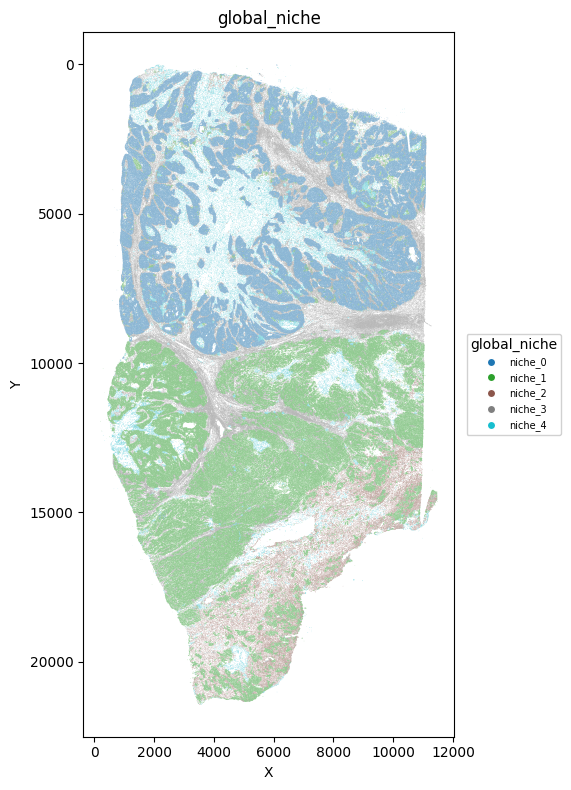

In [8]:
sj.visualization.xenium_plot_spatial(sp_fov, 
                                     values='global_niche', 
                                     save_dir='xenium_plots',
                                     mode='polygon', 
                                     show=True) # Do not recommend for big data because polygons plotting takes a much longer time with the same visual information

  Saved: xenium_plots/xenium_epcam_dot_continuous.png


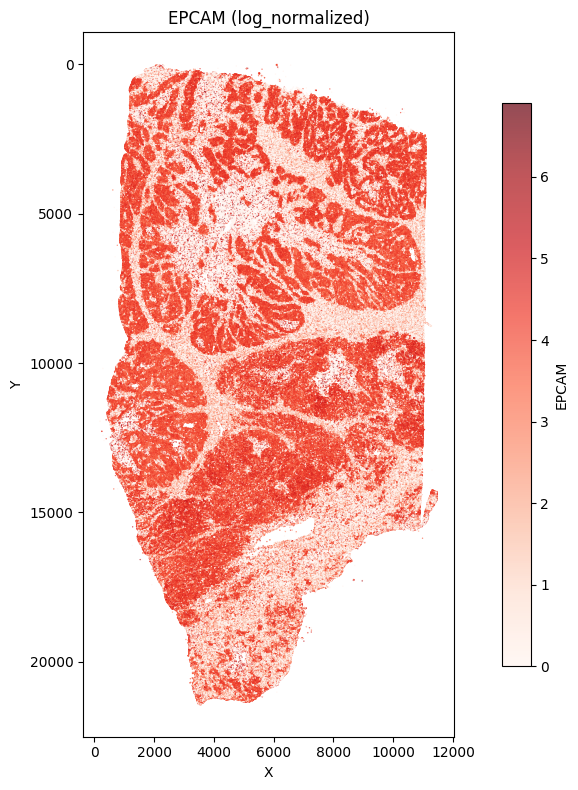

In [6]:
sj.visualization.xenium_plot_spatial(sp_fov, 'EPCAM', layer='log_normalized',
      mode='dot', cmap='Reds',
      save_dir='xenium_plots')

Converting to GeoDataFrame (global coordinates)...
  ✓ Created GeoDataFrame: 1134555 cells
  Saved: xenium_plots/xenium_epcam_polygon_continuous.png


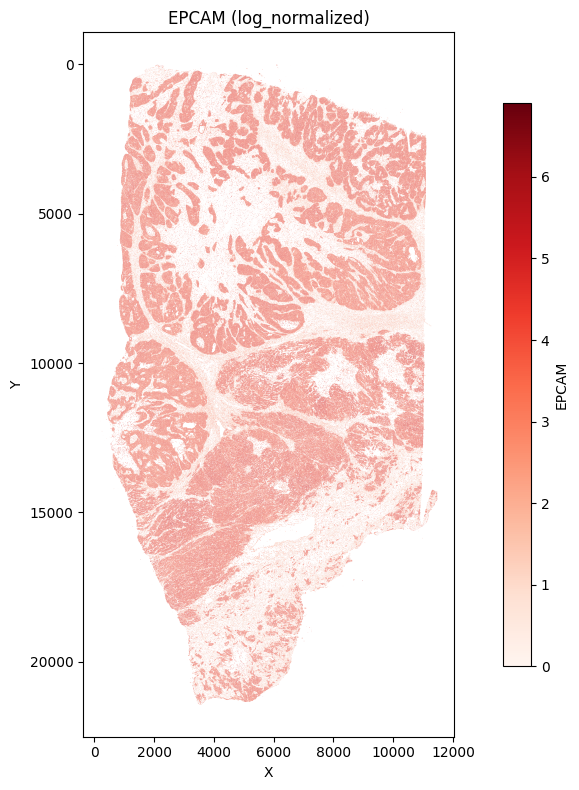

In [9]:
sj.visualization.xenium_plot_spatial(sp_fov, 'EPCAM', layer='log_normalized',
      mode='polygon', cmap='Reds',
      save_dir='xenium_plots')

  ⚠ 1 gene names not found
  Saved: xenium_plots/xenium_morph_elongation_dot_continuous.png


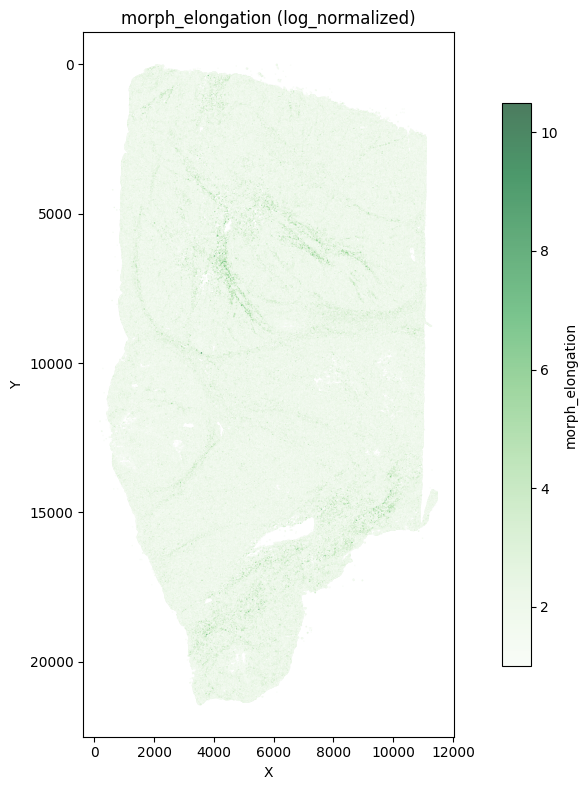

In [11]:
sj.visualization.xenium_plot_spatial(sp_fov, 'morph_elongation', layer='log_normalized',
      mode='dot', cmap='Greens',
      save_dir='xenium_plots')

  Saved: xenium_plots/xenium_leiden_on_morphology_focus_0000.ome_dot.png


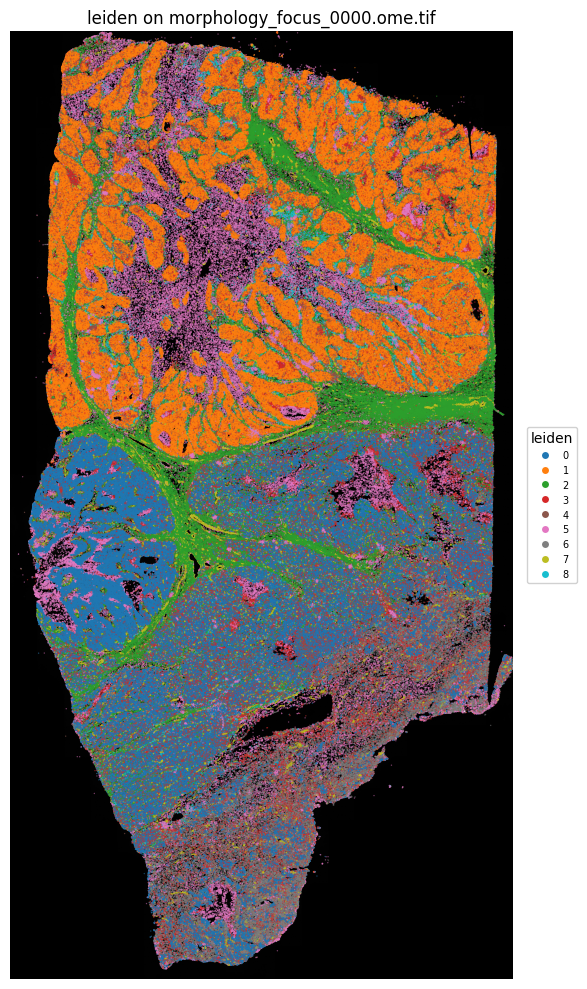

In [6]:
sj.visualization.xenium_plot_spatial_bg(
  sp_fov, '../../Xenium_5k/morphology_focus/morphology_focus_0000.ome.tif',
  values='leiden', bg_level=3,
  save_dir='xenium_plots')

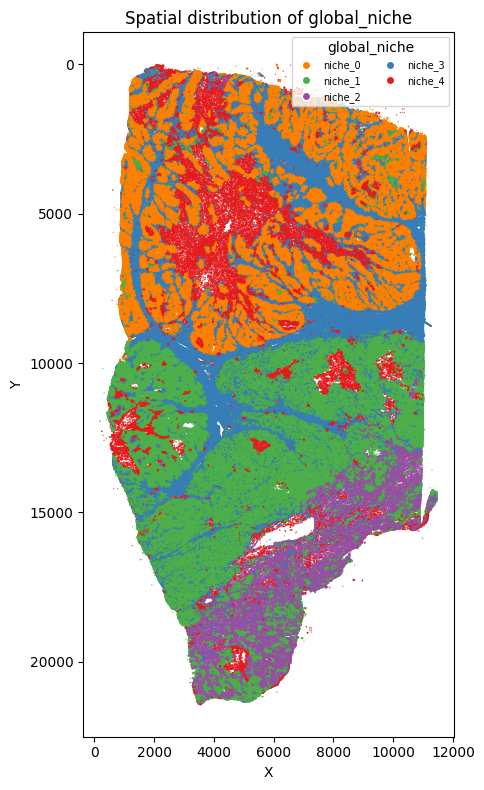

In [17]:
cluster_ids = sp_fov.cell_meta["global_niche"].astype(str)
unique_clusters = sorted(cluster_ids.dropna().unique())

# --- generate random tab10 colors ---
cmap = plt.get_cmap("Set1")
rng = np.random.default_rng(42)
color_indices = rng.permutation(len(unique_clusters)) % 10

color_dict = {cl: cmap(i) for cl, i in zip(unique_clusters, color_indices)}

colors = cluster_ids.map(color_dict)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=colors,
    s=1,
    alpha=0.7,
    linewidths=0
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of global_niche")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# --- legend ---
legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=cl,
        markerfacecolor=color_dict[cl],
        markersize=6
    )
    for cl in unique_clusters
]

ax.legend(
    handles=legend_elements,
    title="global_niche",
    loc="upper right",
    ncol=2,
    fontsize=7
)

plt.tight_layout()
plt.show()

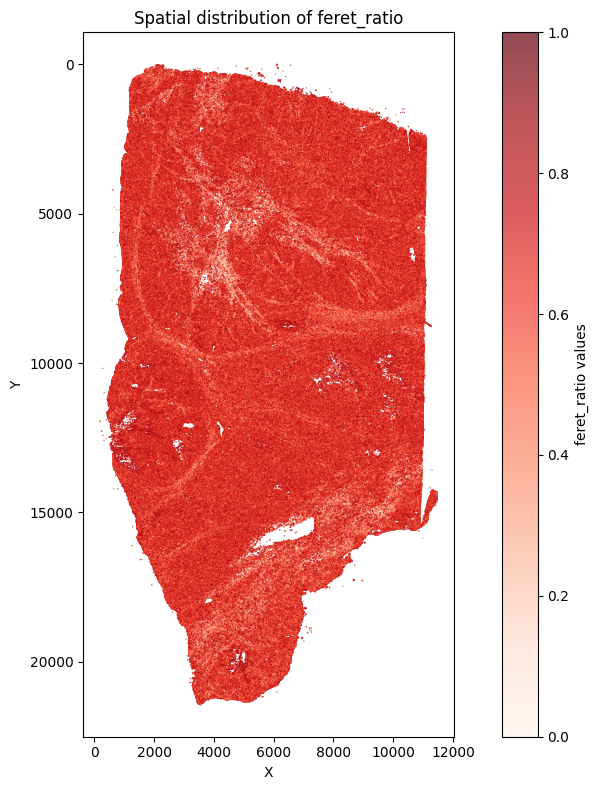

In [20]:
values = sp_fov.cell_meta["morph_"+"feret_ratio"]

fig, ax = plt.subplots(figsize=(10,8))

sc = ax.scatter(
    sp.cell_meta["x_centroid"],
    sp.cell_meta["y_centroid"],
    c=values,              # continuous values
    cmap="Reds",        # continuous colormap
    s=1,
    alpha=0.7,
    linewidths=0,
    vmin=0,
    vmax=1
)

ax.set_aspect("equal")
ax.invert_yaxis()

ax.set_title("Spatial distribution of feret_ratio")
ax.set_xlabel("X")
ax.set_ylabel("Y")

# colorbar instead of legend
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("feret_ratio values")

plt.tight_layout()
plt.show()

## Point-based Analysis

In [5]:
# ── User settings — update these to match your data ──────────────────────────

LAYER         = 'log_normalized'    # layer to use for all gene analysis
                              # must exist in sp.layers (sp.add_layer(...))
CELL_TYPE_COL = 'leiden'     # cell type column in cell_meta
K_NEIGHBORS   = 10           # KNN graph connectivity

# Genes to run full permutation Moran's I + LISA + Gi* on
GENES_OF_INTEREST = ['EPCAM', 'THY1']   # ← replace with your genes

# Cell type pairs for cross-type distance (source → target)
CROSS_TYPE_PAIRS = [
    ('0', '1'),
    ('1', '2'),
]

# ── Verify layer exists before starting ──────────────────────────────────────
if LAYER not in sp.layers:
    raise ValueError(
        f"Layer '{LAYER}' not found. "
        f"Available: {sp.list_layers()}. "
        f"Add it with: sp.add_layer('{LAYER}', your_matrix)"
    )
print(f"Using layer '{LAYER}' for gene-level spatial analysis.")


Using layer 'log_normalized' for gene-level spatial analysis.


In [6]:
# ── Collectors ────────────────────────────────────────────────────────────────
svg_all          = []   # SVG results per FOV
morans_all       = []   # global Moran's I for genes of interest
lisa_all         = {}   # {fov_id: {gene: LISA DataFrame}}
gi_all           = {}   # {fov_id: {gene: Gi* DataFrame}}
enrich_point_all = {}   # centroid-based neighborhood enrichment
ripley_all       = {}   # {fov_id: {cell_type: envelope}}
cross_dist_all   = []   # cross-type distances
nnd_all          = []   # nearest neighbor distances


for fov_id, sp_fov in iter_fovs(sp):
    print(f"\n{'='*55}\nFOV: {fov_id}  ({sp_fov.n_cells} cells)\n{'='*55}")

    # ── Step 1: KNN graph ─────────────────────────────────────────────────────
    # Centroid-based, stays FOV-local
    graph = spoint.build_knn_graph(sp_fov, k=K_NEIGHBORS, coord_type='global')

    # ── Step 2: SVG screening (all genes, fast analytical Moran's I) ─────────
    # Runs on normalized layer → fair comparison across genes
    # Use for discovery; validate top hits with full permutation in Step 3
    svg = spoint.spatially_variable_genes(
        sp_fov, graph,
        layer=LAYER,
        n_top=50,
        fdr_threshold=0.05
    )  # → pd.DataFrame: gene × [I, expected, variance, zscore, pvalue, fdr]
    svg['fov'] = fov_id
    svg_all.append(svg)

    # ── Step 3: Global Moran's I (full permutation, genes of interest) ────────
    # More robust than analytical Step 2 — use for genes you want to report
    # I > 0 → spatially clustered, I < 0 → dispersed, I ≈ 0 → random
    morans_rows = []
    for gene in GENES_OF_INTEREST:
        if gene not in sp_fov.gene_index:
            continue
        result = spoint.morans_i(
            sp_fov, graph,
            values=gene,
            layer=LAYER,
            local=False,
            n_permutations=999,   # use 199 during development for speed
            seed=42
        )  # → dict: I, expected, zscore, pvalue
        morans_rows.append({'gene': gene, 'fov': fov_id, **result})
    if morans_rows:
        morans_all.append(pd.DataFrame(morans_rows))

    # ── Step 4: Local Moran's I / LISA ───────────────────────────────────────
    # WHERE does each gene cluster spatially?
    # HH = high-expression cluster, LL = low-expression cluster
    # HL/LH = spatial outliers, ns = not significant
    fov_lisa = {}
    for gene in GENES_OF_INTEREST:
        if gene not in sp_fov.gene_index:
            continue
        lisa = spoint.morans_i(
            sp_fov, graph,
            values=gene,
            layer=LAYER,
            local=True,           # ← LISA mode
            n_permutations=199,
            seed=42
        )  # → pd.DataFrame: local_i, zscore, pvalue, spot_type (indexed by cell_id)
        lisa['fov'] = fov_id
        fov_lisa[gene] = lisa
    lisa_all[fov_id] = fov_lisa

    # ── Step 5: Getis-Ord Gi* hotspots per gene ───────────────────────────────
    # Gi* > 0, p < 0.05 → hotspot (high-expression spatial cluster)
    # Gi* < 0, p < 0.05 → coldspot
    # Unlike Moran's I, Gi* tells you the DIRECTION of clustering
    fov_gi = {}
    for gene in GENES_OF_INTEREST:
        if gene not in sp_fov.gene_index:
            continue
        gi = spoint.getis_ord_gi(
            sp_fov, graph,
            values=gene,
            layer=LAYER,
            star=True,
            permutation_pvalue=False,  # analytical (fast); True for publication
            store=False
        )  # → pd.DataFrame: gi, zscore, pvalue, spot_type (indexed by cell_id)
        gi['fov'] = fov_id
        fov_gi[gene] = gi
    gi_all[fov_id] = fov_gi

    # ── Step 6: Centroid-based neighborhood enrichment ────────────────────────
    # Compare with polygon enrichment (Section 2, Step 5):
    # differences reveal contact-topology vs. pure spatial proximity effects
    enrich = spoint.neighborhood_enrichment(
        sp_fov, graph,
        cell_type_col=CELL_TYPE_COL,
        n_permutations=500,
        seed=42
    )
    enrich_point_all[fov_id] = {
        'z_scores' : enrich['zscore'],
        'p_values' : enrich['pvalue'],
        'observed' : enrich['observed'],
        'expected' : enrich['expected'],
    }

    # ── Step 7: Ripley's L per cell type ─────────────────────────────────────
    # L(r) > 0 → cells cluster at radius r (relative to CSR)
    # L(r) < 0 → cells disperse at radius r
    # L(r) = 0 → complete spatial randomness (CSR)
    fov_ripley = {}
    for cell_type in sp_fov.cell_meta[CELL_TYPE_COL].dropna().unique():
        cell_ids = sp_fov.cell_meta.index[
            sp_fov.cell_meta[CELL_TYPE_COL] == cell_type
        ].tolist()

        if len(cell_ids) < 10:   # too few cells for reliable estimate
            continue

        envelope = spoint.simulation_envelope(
            sp_fov,
            function='L',
            cell_ids=cell_ids,
            n_simulations=99,    # increase to 999 for publication
            coord_type='global',
            seed=42
        )
        fov_ripley[cell_type] = envelope
    ripley_all[fov_id] = fov_ripley

    # ── Step 8: Cross-type distances ─────────────────────────────────────────
    # For each source cell: distance to its nearest target-type cell
    # Asymmetric: dist(A→B) ≠ dist(B→A)
    for source_type, target_type in CROSS_TYPE_PAIRS:
        types_present = sp_fov.cell_meta[CELL_TYPE_COL].dropna().unique()
        if source_type not in types_present or target_type not in types_present:
            continue

        dist_df = spoint.cross_type_distances(
            sp_fov,
            cell_type_col=CELL_TYPE_COL,
            source_type=source_type,
            target_type=target_type,
            coord_type='global',
            k=1,
            store=False
        )  # → pd.DataFrame: distance, target_cell_id (indexed by source cell_id)
        dist_df['source_type'] = source_type
        dist_df['target_type'] = target_type
        dist_df['fov'] = fov_id
        cross_dist_all.append(dist_df)

    # ── Step 9: Nearest neighbor distances ───────────────────────────────────
    # How close is each cell to its nearest neighbor?
    # Compare across FOVs to detect density differences between tissue regions
    nnd = spoint.nearest_neighbor_distances(
        sp_fov,
        coord_type='global',
        cell_type_col=CELL_TYPE_COL,
        k=1,
        store=False
    )  # → pd.DataFrame: nnd, nn_cell_id (indexed by cell_id)
    nnd['fov'] = fov_id
    nnd_all.append(nnd)


# ── Combine per-FOV results ───────────────────────────────────────────────────
svg_df        = pd.concat(svg_all)
nnd_df        = pd.concat(nnd_all)
cross_dist_df = pd.concat(cross_dist_all) if cross_dist_all else pd.DataFrame()
morans_df     = pd.concat(morans_all)     if morans_all     else pd.DataFrame()

# lisa_all and gi_all kept as nested dicts {fov_id: {gene: DataFrame}}
# Access example: lisa_all['001']['GeneA']



Subsetting by FOVs: 1 FOVs requested

Subsetting by cells: 1134555 cells requested

Initializing spatioloji
[1/11] Master indices: 1,134,555 cells × 5,001 genes
[2/11] Expression matrix: sparse (10899.5 MB)
[3/10] Cell metadata: 83 columns
[4/11] Gene metadata: 15 columns
[5/11] Spatial coordinates: 1134555 cells
[6/11] Polygons: 28363705 vertices for 1134555 cells
[7/11] Images: 0 total, 0 loaded
[8/11] FOV system: 1 FOVs
[9/11] Index maps created
[10/11] Validation: ✓ All consistent
[11/11] Layers and Embeddings initialized (empty)

Spatioloji Object Summary:
  Cells:              1,134,555
  Genes:              5,001
  FOVs:               1
  Images:             0 (0 loaded)
  Original Expression:         sparse
  Has polygons:       True
  Memory (approx):    14482.0 MB

✓ Created subset: 1134555 cells, 1 FOVs
  Layers subsetted (cell axis): ['normalized_counts', 'log_normalized', 'scaled']
  Embeddings subsetted: ['X_pca', 'X_pca_variance', 'X_pca_variance_ratio', 'X_umap']

FOV:

In [15]:
nnd_all

[                  nnd  nn_cell_id     fov
 cell_id                                  
 aaaaapbh-1   8.736278  aaaabngi-1  xenium
 aaaabakn-1  10.966737  eepfepik-1  xenium
 aaaabhic-1   6.957397  eepfbdej-1  xenium
 aaaabngi-1   8.210352  aaaddhjo-1  xenium
 aaaabnhl-1   7.657216  eepcgehf-1  xenium
 ...               ...         ...     ...
 oilncghd-1  12.363184  ocncjcbm-1  xenium
 oilnefna-1   9.477523  dkilfcdb-1  xenium
 oilnenmm-1   9.203616  ocnfohmp-1  xenium
 oilnfbml-1   8.502311  oilngggn-1  xenium
 oilngggn-1   8.502311  oilnfbml-1  xenium
 
 [1134555 rows x 3 columns]]

  1. area

  - Formula: Shoelace formula on polygon vertices
  - Unit: coordinate units²
  - Range: > 0
  - Interpretation: Cell size. Larger area → swollen, activated, or apoptotic cells. Smaller → tightly packed epithelium.
  - Downstream use: Normalize expression counts (counts/area), filter segmentation artifacts (extremely small/large), compare cell types, input
   to morphology_by_group and morphology_gene_correlation.

  2. perimeter

  - Formula: Sum of edge lengths around polygon boundary
  - Unit: coordinate units
  - Range: > 0
  - Interpretation: Boundary length. Long perimeter relative to area → irregular or ruffled membrane.
  - Downstream use: Input to circularity calculation. Perimeter/area ratio is itself a complexity measure.

  3. circularity

  - Formula: 4π × area / perimeter²
  - Range: (0, 1]
  - Interpretation: 1.0 = perfect circle, →0 = increasingly irregular/elongated. Isoperimetric quotient — how efficiently the boundary encloses
   area.
  - Downstream use: classify_morphology threshold (round vs irregular), morphology_by_group to compare cell types, input to context features.  

  4. elongation

  - Formula: major_axis / minor_axis of the minimum rotated rectangle (MRR)
  - Range: [1, ∞)
  - Interpretation: 1.0 = isometric, 2.0 = twice as long as wide. Captures cell polarity.
  - Downstream use: classify_morphology threshold (elongated cells), fibroblast/stromal detection, migration polarity analysis, input to       
  elongation_alignment.

  5. solidity

  - Formula: area / convex_hull_area
  - Range: (0, 1]
  - Interpretation: 1.0 = fully convex, < 1 = has concavities (indentations). Captures membrane protrusions, pseudopods, dividing cells.       
  - Downstream use: classify_morphology threshold (irregular cells), distinguish activated macrophages (low solidity) from quiescent ones.     

  6. compactness

  - Formula: √(4 × area / π) / major_axis
  - Range: (0, 1]
  - Interpretation: Ratio of equivalent circle diameter to longest axis. 1.0 = circle. Differs from circularity by being insensitive to        
  boundary roughness — only cares about overall proportions.
  - Downstream use: Alternative to circularity when boundary quality is noisy (low-resolution segmentation).

  7. convexity

  - Formula: convex_hull_perimeter / perimeter
  - Range: (0, 1]
  - Interpretation: 1.0 = smooth boundary, < 1 = rough/indented boundary. Complementary to solidity — convexity measures boundary roughness    
  while solidity measures area loss.
  - Downstream use: Membrane ruffling quantification, segmentation quality check (very low convexity may indicate over-segmentation).

  8. contour_entropy

  - Formula: Shannon entropy of turning angle histogram (16 bins) along boundary
  - Range: [0, 4] (log₂ of 16 bins)
  - Interpretation: High entropy = diverse turning angles = irregular shape. Low entropy = uniform angles = regular shape (circle or polygon). 
  Captures boundary complexity differently from circularity.
  - Downstream use: Distinguishes shapes that have similar circularity but different boundary texture (e.g., star vs. amoeba).

  9. rectangularity

  - Formula: area / minimum_rotated_rectangle_area
  - Range: (0, 1]
  - Interpretation: 1.0 = perfect rectangle, < 1 = deviates from rectangular. High for epithelial cells in sheets, low for irregular/stellate  
  cells.
  - Downstream use: Epithelial vs. mesenchymal classification, tissue architecture quantification.

  10. eccentricity

  - Formula: √(1 − (minor/major)²) from MRR axes
  - Range: [0, 1)
  - Interpretation: 0 = circle, →1 = line. Compresses the high end of elongation into [0,1), making it better for statistical tests (less      
  skewed distribution).
  - Downstream use: Alternative to elongation for regression/correlation analyses where bounded range helps.

  11. feret_max

  - Formula: Maximum pairwise distance between convex hull vertices (max caliper distance)
  - Unit: coordinate units
  - Range: > 0
  - Interpretation: True cell span — the longest straight-line distance across the cell at any angle. Rotation-invariant unlike bounding box.  
  - Downstream use: Absolute cell size measurement (scale-dependent), T cell vs. tumor size comparison, filter giant segmentation artifacts.   

  12. feret_min

  - Formula: Minimum width across all edge-normal projections of the convex hull
  - Unit: coordinate units
  - Range: > 0
  - Interpretation: Narrowest dimension of the cell. Small feret_min relative to feret_max → highly elongated.
  - Downstream use: Detect narrow cell processes (e.g., dendritic cell extensions), combined with feret_max for aspect ratio.

  13. feret_ratio

  - Formula: feret_min / feret_max
  - Range: (0, 1]
  - Interpretation: 1.0 = isometric, →0 = extremely elongated. More robust than MRR elongation for irregular shapes since it uses the convex   
  hull.
  - Downstream use: Robust elongation measure for noisy boundaries, alternative to elongation/eccentricity.

  14. n_concavities

  - Formula: Count of polygon regions in convex_hull.difference(cell_polygon)
  - Range: 0, 1, 2, ...
  - Interpretation: 0 = convex cell, 1 = one indentation, 2+ = multiple. Captures dividing cells (1 cleavage furrow), phagocytosing cells,     
  stellate morphology.
  - Downstream use: Detect mitotic cells (n_concavities = 1 + circularity drop), identify activated immune cells with pseudopods, segmentation 
  QC.

  ---
  Spatial Context Metrics (6) — compute_context_morphology()

  Stored as ctx_morph_* in cell_meta. Require a polygon graph.

  15. area_ratio_neighbors

  - Formula: cell_area / mean(neighbor_areas)
  - Range: > 0
  - Interpretation: > 1 = cell is larger than its neighbors, < 1 = smaller. Identifies swollen/compressed cells relative to local context, not 
  absolute size.
  - Downstream use: Detect locally enlarged cells (edema, activation), compressed cells at tissue boundaries, size-independent of FOV scale.   

  16. circularity_deviation

  - Formula: |cell_circularity − mean(neighbor_circularity)|
  - Range: [0, 1]
  - Interpretation: High = this cell's shape is different from its neighbors. Identifies shape outliers in local tissue context.
  - Downstream use: Detect invading cells (different shape from surrounding tissue), transitional cells at tissue boundaries, segmentation     
  errors.

  17. elongation_alignment

  - Formula: mean(cos(2 × Δθ)) where Δθ is the angle between the cell's major axis and each neighbor's major axis
  - Range: [−1, 1]
  - Interpretation: +1 = cell is parallel to neighbors, −1 = perpendicular, 0 = random orientation. Uses cos(2θ) because axis direction is     
  ambiguous (0° = 180°).
  - Downstream use: Detect aligned fibroblast/stromal bundles, smooth muscle orientation, collagen-aligned cancer invasion fronts.

  18. local_shape_heterogeneity

  - Formula: std(neighbor_circularity_values)
  - Range: ≥ 0
  - Interpretation: High at tissue boundaries where different cell types meet (heterogeneous shapes), low inside homogeneous regions.
  - Downstream use: Automatic tissue boundary detection without cell type labels, identify tumor-stroma interfaces, spatial domain
  segmentation.

  19. morphological_outlier_score

  - Formula: Mahalanobis distance of (area, circularity, elongation) from neighborhood mean/covariance
  - Range: ≥ 0
  - Interpretation: Multi-metric outlier detection. High score = this cell is morphologically unusual compared to neighbors across all shape   
  dimensions simultaneously.
  - Downstream use: Flag cells for manual review, detect rare infiltrating cells, identify transition zones, QC filter for segmentation        
  artifacts.

  20. area_ratio_voronoi

  - Formula: cell_polygon_area / voronoi_cell_area (Voronoi from centroids, clipped to tissue bounding box)
  - Range: (0, 1] typically
  - Interpretation: How much of its territorial space the cell fills. High = densely packed (cell fills its Voronoi territory), low = sparse   
  with extracellular space.
  - Downstream use: Extracellular matrix density estimation, tissue compaction measurement, distinguish loose stroma from compact epithelium   
  without requiring explicit ECM segmentation.